# Begin

In [1]:
# @launchit.collected

In [42]:
import os # @launchit.collect
import sys # @launchit.collect
import copy
from collections import namedtuple, defaultdict # @launchit.collect
import json
import datetime
import pprint
from functools import cache
import re
import pickle
from unittest.mock import Mock
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import IPython
from enum import Flag, StrEnum, auto # @launchit.collect
import multiprocessing as mp

from tqdm.notebook import tqdm

import lark # @launchit.collect

import numpy as np
import einops
import scipy.linalg
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim
from torch.utils.data import DataLoader, StackDataset
from torchvision import datasets

import optuna 
from optuna.storages import JournalStorage 
from optuna.storages.journal import JournalFileBackend 
from optuna.trial import TrialState

project_root_path = '${PROJECT_ROOT_PATH}' # @launchit.collect
# @launchit.disable
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]
# @launchit.stop

sys.path.append(os.path.join(project_root_path, 'lib')) # @launchit.collect
from utils import * # @launchit.collect
from logging_utils import *
from model_registry import *
import launchit # @launchit.disable
import optuna_multiprocessing  # @launchit.collect_2
from metrics_collector import RmqSummaryWriter
from autoincrement import Autoincrement

# Setup

In [3]:
LOG = Logging.get()
RNG = np.random.default_rng()
METRICS_SUITE = defaultdict(list)

class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, subproject_path, data_path, mnist_path, private_data_path, run_path, ' + 
                    'self_fname, self_name, ' +
                    'subproject_name,' +
                    'is_cuda, cuda_device, exec_mode, is_interactive')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    subproject_path=os.path.abspath('.'),
    data_path=os.path.join(project_root_path, 'data'),
    mnist_path=os.path.join(project_root_path, 'data', 'mnist'),
    private_data_path=None,
    run_path=None,
    self_fname=None,
    self_name=None,
    subproject_name=None,
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
    exec_mode=ExecMode.MASTER_NOTEBOOK,
    is_interactive=True,
)

if IPython.get_ipython() is None:
    module_fname = __file__
    module_basename = os.path.basename(module_fname)
    module_name, _ = os.path.splitext(module_basename)
    
    CONFIG = CONFIG._replace(self_fname=module_fname, self_name=module_name)
    CONFIG = CONFIG._replace(exec_mode=ExecMode.LAUNCH_MODULE)
else:
    with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
        notebook_fname = json.load(cf)['jupyter_session']
        notebook_basename = os.path.basename(notebook_fname)
        notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    
        m = re.match(r'(\w+)-Copy\d+$', notebook_name)
    
        if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook

        CONFIG = CONFIG._replace(self_fname=notebook_fname, self_name=notebook_name)
        
        is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None
        CONFIG = CONFIG._replace(exec_mode=ExecMode.MASTER_NOTEBOOK if not is_launch else ExecMode.LAUNCH_NOTEBOOK)

CONFIG = CONFIG._replace(is_interactive=CONFIG.exec_mode != ExecMode.LAUNCH_MODULE)

LOG.app_name = CONFIG.self_name
LOG.enable('syslog', not CONFIG.is_interactive)
LOG.enable('stdout', CONFIG.is_interactive)

CONFIG = CONFIG._replace(subproject_name=os.path.basename(os.path.dirname(CONFIG.self_fname)))
CONFIG = CONFIG._replace(run_path=os.path.join(project_root_path, 'run', CONFIG.subproject_name))
CONFIG = CONFIG._replace(private_data_path=os.path.join(CONFIG.data_path, CONFIG.subproject_name))
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)

os.makedirs(CONFIG.private_data_path, exist_ok=True)
os.makedirs(CONFIG.run_path, exist_ok=True)

CONFIG=
{'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision',
 'subproject_path': '/home/misha/dev/mine/neurovision/11_cnn',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'mnist_path': '/home/misha/dev/mine/neurovision/data/mnist',
 'private_data_path': '/home/misha/dev/mine/neurovision/data/11_cnn',
 'run_path': '/home/misha/dev/mine/neurovision/run/11_cnn',
 'self_fname': '/home/misha/dev/mine/neurovision/11_cnn/s4_psd_01.ipynb',
 'self_name': 's4_psd_01',
 'subproject_name': '11_cnn',
 'is_cuda': False,
 'cuda_device': 'cpu',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



In [4]:
# @launchit.disable
# @launchit.collect
class LaunchGoal(StrEnum):
    UNSPECIFIED = auto()
    PRETRAIN_KERNELS = auto()

class LaunchGoalObj(namedtuple('LaunchGoalObj', 'goal, model_group_uri, model_name, model_version, model_main_asset_fname')):
    def matches(self, *g):
        if CONFIG.exec_mode == ExecMode.MASTER_NOTEBOOK:
            return True
            
        if g and isinstance(g[0], list):
            assert len(g) == 1
            return self.goal in g[0]

        return self.goal in g

LAUNCH_GOAL = LaunchGoalObj(
    goal=LangUtils.from_str(LaunchGoal, '${LAUNCH_GOAL}', LaunchGoal.UNSPECIFIED),
    model_group_uri='${MODEL_GROUP_URI}',
    model_name='${MODEL_NAME}',
    model_version=LangUtils.from_str(int, '${MODEL_VERSION}', 0),
    model_main_asset_fname='${LAUNCHIT_FNAME}',
)
# @launchit.stop

LAUNCH_GOAL = LAUNCH_GOAL._replace(goal=LaunchGoal.UNSPECIFIED)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_group_uri=f'{CONFIG.project_root_uri}.{CONFIG.subproject_name}')
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_name=CONFIG.self_name)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_version=0)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_main_asset_fname=CONFIG.self_fname)
# @launchit.stop

LOG(f'LAUNCH_GOAL=\n{pprint.pformat(LAUNCH_GOAL._asdict(), sort_dicts=False)}', when=CONFIG.is_interactive)
LOG(f'LAUNCH_GOAL={LAUNCH_GOAL._asdict()}', when=not CONFIG.is_interactive)

LAUNCH_GOAL=
{'goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'model_group_uri': 'com.develorium.neurovision.11_cnn',
 'model_name': 's4_psd_01',
 'model_version': 0,
 'model_main_asset_fname': '/home/misha/dev/mine/neurovision/11_cnn/s4_psd_01.ipynb'}


# Hyperparameters

In [5]:
# @launchit.disable
# @launchit.collect
@dataclass
class Hyperparameters:
    random_seed: int = None
    images_preprocessing: str = None
    patches_count: int = None
    kernels_count: int = None
    kernel_size: int = None
    basis_pursuit_solver: str = None # ISTA, LISTA
    basis_pursuit_rho: float = None
    basis_pursuit_iters_count: int = None
    sparsity: float = None # aka λ
    batch_size: int = None
    epochs_count: int = None
    optimizer: str = None
    learn_rate: float = None

    @staticmethod
    def from_dict(d):
        hp = Hyperparameters(**d)
        return hp

    def _asdict(self):
        return dataclasses.asdict(self)

HP = Hyperparameters()
HP.random_seed = 42
HP.kernel_size = 5


# Launch

## new_model_registry

In [6]:
def new_model_registry(is_real=None):
    is_launch = CONFIG.exec_mode in [ExecMode.LAUNCH_NOTEBOOK, ExecMode.LAUNCH_MODULE]
    is_real = is_real if is_real is not None else is_launch

    if not is_real:
        mr = Mock()
        mr.register_model.return_value = 0
        return mr
        
    return ModelRegistry(LAUNCH_GOAL.model_group_uri)

## new_summary_writer

In [7]:
def new_summary_writer(log_dir, is_real=None):
    is_launch = CONFIG.exec_mode in [ExecMode.LAUNCH_NOTEBOOK, ExecMode.LAUNCH_MODULE]
    is_real = is_real if is_real is not None else is_launch

    if not is_real:
        sw = Mock()
        sw.flush.side_effect = sw.reset_mock # to get rid of all recorded call_args_list, which might be heavy (e.g. add_figure)
        return sw
    
    return RmqSummaryWriter(log_dir)

## Bootstrap

In [8]:
optuna_trial = optuna_multiprocessing.get_trial()

if optuna_trial is not None:
    optuna_trial.set_user_attr('MODEL_VERSION', LAUNCH_GOAL.model_version)
    LOG(f'Optuna {optuna_trial.number=}, {optuna_trial.user_attrs=}')

LOG(f'HP={HP._asdict()}', when=not CONFIG.is_interactive)
    
if HP.random_seed is not None:
    torch.manual_seed(HP.random_seed)
    RNG = np.random.default_rng(HP.random_seed)    
    LOG(f'Random seed={HP.random_seed}')

model_registry = new_model_registry()
model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, CONFIG.self_fname, replace=True)
    
meta = dict(
    optuna_trial_number=getattr(optuna_trial, 'number', None),
    hypers=HP._asdict(), 
    config=CONFIG._asdict(), 
)

with io.StringIO() as b:
    json.dump(meta, b)
    model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='json', asset_classifier='meta', replace=True)

summary_log_dir = os.path.join(LAUNCH_GOAL.model_name, str(LAUNCH_GOAL.model_version))
LOG(f'Tensorboard run={summary_log_dir}')
summary_writer = new_summary_writer(log_dir=summary_log_dir)
summary_writer.add_text('hypers', pprint.pformat(HP._asdict(), sort_dicts=False), 1)
summary_writer.add_text('config', pprint.pformat(CONFIG._asdict(), sort_dicts=False), 1)

Random seed=42
Tensorboard run=s4_psd_01/0


<Mock name='mock.add_text()' id='129668706653664'>

# Images

## get_mnist_images

In [9]:
def get_mnist_images(subdataset='TRAIN'):
    assert subdataset in ['TRAIN', 'TEST'], f'Unsupported subdataset={subdataset}'
    d = datasets.MNIST(CONFIG.mnist_path, train=subdataset=='TRAIN', download=True)
    images = d.data.numpy()
    images = images.astype('float32')
    image_labels = d.targets
    return images, image_labels

## UninormScaler

In [10]:
class UninormScaler:
    def __init__(self, divisor=255.0):
        self.divisor = divisor
        
    def fit_transform(self, images):
        return self.transform(images)

    def transform(self, images):
        return images / self.divisor

## SampleWiseScaler

In [11]:
# https://gist.github.com/kocherovms/ca352c30fe3eea0f155d4862ddde6e3a for tests and breakdown
class SampleWiseScaler:
    def fit_transform(self, images):
        return self.transform(images)

    # Images are expected to be in raveled (flattened) mode => only last dim is taken into account
    def transform(self, images):
        shape = images.shape
        images = images.reshape(-1, images.shape[-1]) # get rid of all dimensions except the last one
        means = images.mean(axis=-1)
        stds = images.std(axis=-1)
        images = images.T - means
        images = images / np.where(stds != 0, stds, 1)
        images = images.T
        return images.reshape(shape)

## preprocess_images

In [12]:
# images are expected to be in raveled (flattened) mode
def preprocess_images(images, preprocessing_method, scaler=None):
    match preprocessing_method:
        case 'UNINORM':
            scaler = UninormScaler() if scaler is None else scaler
            images = scaler.fit_transform(images)
        case 'SAMPLE_WISE':
            scaler = SampleWiseScaler() if scaler is None else scaler
            images = scaler.fit_transform(images)
        case 'MIN_MAX':
            scaler = MinMaxScaler() if scaler is None else scaler
            images = scaler.fit_transform(images)
        case 'STANDARDIZE':
            scaler = StandardScaler() if scaler is None else scaler
            images = scaler.fit_transform(images)
        case 'ZCA_WHITEN':
            scaler = StandardScaler(with_std=False) if scaler is None else scaler
            images = scaler.fit_transform(images)
            
            Σ = np.cov(images, rowvar=False)
            u, s, _ = np.linalg.svd(Σ)
            images = (u @ np.diag(1.0 / np.sqrt(s + 1e-6)) @ u.T @ images.T).T
        case 'ZCA_HFR30_WHITEN': # HFR30 - Remove 30% of High Frequencies
            scaler = StandardScaler(with_std=False) if scaler is None else scaler
            images = scaler.fit_transform(images)
    
            Σ = np.cov(images, rowvar=False)
            eigvals, eigvecs = np.linalg.eig(Σ)
            eigvals_order = np.argsort(-eigvals)
            wipeout_inds = eigvals_order[int(len(eigvals_order) * (1 - 0.3)):]
            eigvals_w = eigvals.copy()
            eigvals_w[wipeout_inds] = 0
            
            R, S = eigvecs, np.diag(np.sqrt(eigvals_w)) # R - rotation matrix, S - scale matrix
            S_inv = np.reciprocal(S, out=np.zeros_like(S), where=(S != 0))
            R_inv = R.T
            W = R @ S_inv @ R_inv  # equiv. to: R @ np.eye(len(S_inv)) @ S_inv @ R_inv
            images = (W @ images.T).T
        case 'NONE':
            pass
        case _:
            assert False, f'Unsupported preprocessing_method={preprocessing_method}'

    return images, scaler

## extract_image_patch

In [13]:
ImagePatch = namedtuple('ImagePatch', 'patch image_ind i_off j_off')

def extract_image_patch(images, image_stds, patch_size, image_ind=None, with_std=True):
    blind_area = 4
    trials = 1000
    image_ind = RNG.choice(images.shape[0]) if image_ind is None else image_ind
    image = images[image_ind]
    image_std_thres = image_stds[image_ind] * .1

    for _ in range(trials):
        i_off = blind_area + RNG.choice(image.shape[0] - 2 * blind_area - patch_size)
        j_off = blind_area + RNG.choice(image.shape[1] - 2 * blind_area - patch_size)
        patch = image[i_off:i_off + patch_size, j_off:j_off + patch_size]
        
        if with_std:
            patch_std = patch.ravel().std()
    
            if patch_std < image_std_thres: # This should effectively exclude completely monotonic images (e.g. black or white)
                continue
        
        break
    else:
        assert False, f'Failed to extract image patch within {trials} trials'
    
    return ImagePatch(patch, image_ind, i_off, j_off)

# Dataset

In [14]:
# @launchit.disable
# @launchit.collect
HP.images_preprocessing = 'SAMPLE_WISE' # NONE, UNINORM, SAMPLE_WISE, MIN_MAX, STANDARDIZE, ZCA_WHITEN, ZCA_HFR30_WHITEN
HP.patches_count = 50_000

## get_dataset_fname

In [15]:
def get_dataset_fname():
    fname = f'psd_patches_{HP.patches_count}_{HP.images_preprocessing}_{HP.kernel_size}.npy' 
    return os.path.join(CONFIG.private_data_path, fname)

## Generate patches

In [35]:
# @launchit.disable
assert CONFIG.exec_mode == ExecMode.MASTER_NOTEBOOK
fname = get_dataset_fname()

if not os.path.exists(fname):
    PATCHES = None
    LOG(f'{fname} not found, generating new one')
else:
    PATCHES = np.load(fname)
    shape = einops.parse_shape(PATCHES, 'b h w')

    if shape['b'] != HP.patches_count or shape['h'] != HP.kernel_size or shape['w'] != HP.kernel_size:
        PATCHES = None
        LOG(f'Patches disagree with hyperparameters, regenerating')

if PATCHES is None:
    PATCHES = []
    images, _ = get_mnist_images('TRAIN')
    image_stds = einops.rearrange(images, 'b h w -> b (h w)').std(axis=1)
    
    for i in tqdm(range(HP.patches_count)):
        patch = extract_image_patch(images, image_stds, HP.kernel_size, with_std=True)
        PATCHES.append(patch.patch)

    PATCHES = np.array(PATCHES)
    np.save(fname, PATCHES)
    LOG(f'Patches generated and saved to "{fname}"')

## Load patches

In [75]:
assert os.path.exists(fname), f'{fname} not found'
PATCHES = np.load(fname)
PATCHES = torch.tensor(PATCHES)
shape = einops.parse_shape(PATCHES, 'b h w')
assert shape['b'] == HP.patches_count
assert shape['h'] == HP.kernel_size
assert shape['w'] == HP.kernel_size
PATCHES = einops.rearrange(PATCHES, 'b h w -> b (h w)')
LOG(f'Patches loaded from "{fname}": {PATCHES.shape=}')

Patches loaded from "/home/misha/dev/mine/neurovision/data/11_cnn/psd_patches_50000_SAMPLE_WISE_5.npy": PATCHES.shape=torch.Size([50000, 25])


## Demo

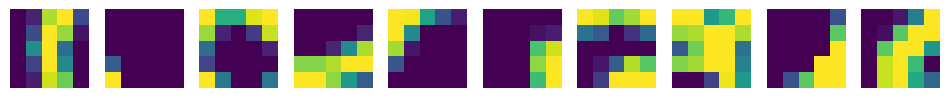

In [152]:
# @launchit.disable
fig, axes = plt.subplots(1, 10)
fig.set_figwidth(12)
patch_inds = RNG.choice(len(PATCHES), len(axes), replace=False)

for patch_ind, ax in zip(patch_inds, axes):
    patch = PATCHES[patch_ind]
    ax.set_axis_off()
    ax.imshow(ArrayUtils.v2sm(patch))

# Basis pursuit

## ISTA

In [51]:
def ista(x, W, rho=0.5, L=1, iters_count=300):
    # W - matrix, each column is a basis
    z = torch.zeros(W.shape[1])
    shrink = torch.nn.Softshrink(lambd=rho / L)
    
    for _ in range(iters_count):
        z_tild = z - 1 / L * (W.T @ (W @ z - x))
        z = shrink(z_tild)
        
    return z

In [65]:
W = torch.randn((25, 32)) # 32 basises each of 25 dims
max_index = W.shape[1] - 1
L = scipy.linalg.eigvalsh(W.t() @ W, subset_by_index=(max_index, max_index)).item()
x = torch.randn(25) # sample of 25 dims
ista(x, W, rho=0.5, L=L, iters_count=10)

tensor([ 0.1736,  0.0408,  0.1534,  0.0000, -0.1332, -0.0949, -0.1078, -0.0077,
         0.1295, -0.3226,  0.0036,  0.1988, -0.0322,  0.1456,  0.0228,  0.1799,
         0.0370, -0.1699,  0.0000,  0.0704,  0.2092, -0.0082, -0.0392, -0.0420,
        -0.0583, -0.0412,  0.2124,  0.0853, -0.2460, -0.2457,  0.1679,  0.1921])

## LISTA

In [21]:
# ...

# Model

## MainModel

In [127]:
class MainModel(nn.Module):
    def __init__(self, hp):
        super().__init__()
        self.W = nn.Linear(in_features=hp.kernels_count, out_features=hp.kernel_size**2, bias=False) # matrix of "reverse" filters, each row = dict elem
        self.K = nn.Linear(in_features=hp.kernel_size**2, out_features=hp.kernels_count, bias=True) # future kernels (what we want to train in PSD), each row = kernel
        #self.g = ... add gain

    ForwardResult = namedtuple('ForwardResult', 'wz xk')

    def forward(self, X, Z):
        # expected X.shape = (batch, image_as_vector)
        # expected Z.shape = (batch, coeffs_as_vector)
        wz = self.W(Z)
        xk = self.regress(X)
        return MainModel.ForwardResult(wz=wz, xk=xk)

    def regress(self, X):
        return F.tanh(self.K(X))        

In [128]:
# @launchit.disable
hp = Hyperparameters(kernels_count=32, kernel_size=5)
model = MainModel(hp)
print(f'{model.W.weight.shape=}')
print(f'{model.K.weight.shape=}')
print(f'Params count={sum([p.numel() for p in model.parameters()])}')
test_X = torch.ones((100, hp.kernel_size**2))
test_Z = torch.ones((100, hp.kernels_count))
fr = model(test_X, test_Z)
print(f'{fr.wz.shape=}, {fr.xk.shape=}')

model.W.weight.shape=torch.Size([25, 32])
model.K.weight.shape=torch.Size([32, 25])
Params count=1632
fr.wz.shape=torch.Size([100, 25]), fr.xk.shape=torch.Size([100, 32])


# Training

## Configure

In [32]:
# @launchit.disable
# @launchit.collect_1
HP.kernels_count = 32
HP.basis_pursuit_solver = 'ISTA'
HP.basis_pursuit_iters_count = 10
HP.basis_pursuit_rho = 0.5
HP.sparsity = 0.2
HP.batch_size = 100
HP.epochs_count = 10
HP.optimizer = 'Adam'
HP.learn_rate = 0.005
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'random_seed': 42,
 'images_preprocessing': 'SAMPLE_WISE',
 'patches_count': 50000,
 'kernels_count': 32,
 'kernel_size': 5,
 'sparcity': None,
 'basis_pursuit_solver': 'ISTA',
 'basis_pursuit_rho': 0.5,
 'basis_pursuit_iters_count': 10,
 'batch_size': 100,
 'epochs_count': 10,
 'optimizer': 'Adam',
 'learn_rate': 0.005}


## Train

In [33]:
# model.W.weight.shape=torch.Size([25, 32])
# model.K.weight.shape=torch.Size([32, 25])

In [ ]:
main_model = MainModel(HP)
optimizer = getattr(torch.optim, HP.optimizer)(main_model.parameters(), lr=HP.learn_rate)
# mse_loss = nn.MSELoss()
pdist = nn.PairwiseDistance(p=2, eps=0)
PATCHES_CUDA = PATCHES.to(CONFIG.cuda_device)

for epoch in tqdm(range(1, HP.epochs_count + 1), desc='Epoch'):
    # Get Z with W and H locked
    Z = torch.zeros((len(PATCHES), HP.kernels_count), device=CONFIG.cuda_device) # factorization coeffs
    
    with torch.no_grad():
        if HP.basis_pursuit_solver == 'ISTA':
            W = main_model.W.weight
            max_index = W.shape[1] - 1
            L = scipy.linalg.eigvalsh((W.t() @ W).to('cpu'), subset_by_index=(max_index, max_index)).item()
            
            for ind, patch in enumerate(PATCHES):
                Z[ind] = ista(patch, W, rho=HP.basis_pursuit_rho, L=L, iters_count=HP.basis_pursuit_iters_count)
        elif HP.basis_pursuit_solver == 'LISTA':
            pass
        else:
            assert False, f'Unsupported {HP.basis_pursuit_solver=}'

    # Train W and K with Z locked
    dataset = StackDataset(PATCHES_CUDA, Z)
    data_loader = DataLoader(dataset, batch_size=HP.batch_size, shuffle=True)
    epoch_loss = dict(all=0, wz=0, λ=0, xk=0)
    epoch_loss_denom = 0, 0

    for batch in data_loader:
        optimizer.zero_grad()
        fr = main_model(batch[0], batch[1])
        wz_loss = pdist(fr.wz, batch[0])
        λ_loss = HP.sparsity * batch[1].abs().sum(axis=1)
        xk_loss = pdist(fr.xk, batch[1])
        loss = wz_loss + λ_loss + xk_loss
        loss = loss.mean()
        loss.backward()
        optimizer.step()

        for k, l in zip(('all', 'wz', 'λ', 'xk'), (loss, wz_loss, λ_loss, xk_loss))
            epoch_loss[k] += l.item() * len(batch)
            
        epoch_loss_denom += len(batch)
        
    if HP.basis_pursuit_solver == 'LISTA':
        # Train LISTA model for fast Z compute
        pass

    assert epoch_loss_denom > 0

    for k in ('all', 'wz', 'λ', 'xk')
        l = epoch_loss[k] / epoch_loss_denom
        k = f'loss_{k}'
        summary_writer.add_scalar(k, l, epoch)
        METRICS_SUITE[k].append(epoch_loss)
        LOG(f'{k}={l}', when=not CONFIG.is_interactive)

    upload_figures = True

    if upload_figures and ((epoch - 1) % 20) == 0:
        # Upload kernel images
        kernes_in_row = 10
        max_kernels_to_show = 100
        kernels = main_model.K.weight.to(device='cpu').detach()
        rows_count = int(np.ceil(min(max_kernels_to_show, len(kernels)) / kernes_in_row))
        fig, axes = plt.subplots(rows_count, kernes_in_row, subplot_kw={'yticks': [], 'xticks': []})
        for ax in axes.ravel(): ax.set_axis_off()
        fig.set_figwidth(12)
        fig.set_figheight(rows_count * 1.5)
        
        if main_model.K.bias is not None:
            biases = main_model.K.bias.to(device='cpu').detach()
            kernels = einops.rearrange(kernels, 'k hw -> hw k')
            kernels = kernels + biases
            kernels = einops.rearrange(kernels, 'hw k -> k hw')
        
        for i, (k, ax) in enumerate(zip(kernels, axes.ravel())):
            k = k.squeeze() 
            ax.set_title(f'#{i}', fontdict=dict(fontsize=10))
            ax.imshow(ArrayUtils.v2sm(k), cmap='gray')
        
        fig.tight_layout()
        summary_writer.add_figure(f'kernels', fig, epoch, close=True)

        # Upload examples
        if epoch == 0:
            example_inds = RNG.choice(len(PATCHES), 10, replace=False)

        fig, axes = plt.subplots(3, len(example_inds))
        fig.set_figwidth(12)
        fig.set_figheight(len(axes) * 1.8)
        for ax in axes.ravel(): ax.set_axis_off()
        W = main_model.W.weight.detach()
        max_index = W.shape[1] - 1
        L = scipy.linalg.eigvalsh((W.t() @ W).to('cpu'), subset_by_index=(max_index, max_index)).item()
        
        for example_ind, (ax0, ax1, ax2) in zip(example_inds, axes.T):
            patch = PATCHES[example_ind]
            ax0.set_title(f'#{example_ind}', fontdict=dict(fontsize=10))
            ax0.imshow(ArrayUtils.v2sm(patch))
            
            ista_z = ista(patch, W, rho=HP.basis_pursuit_rho, L=L, iters_count=HP.basis_pursuit_iters_count)
            ista_patch = W @ ista_z
            ista_l = ((patch - ista_patch) ** 2).sum()
            ax1.set_title(f'{HP.basis_pursuit_solver},\nl={ista_l:.2f}', fontdict=dict(fontsize=10))
            ax1.imshow(ArrayUtils.v2sm(ista_patch))
            
            regress_z = main_model.regress(einops.rearrange(patch, 'v -> 1 v')).squeeze(0).detach()
            regress_patch = W @ regress_z
            regress_l = ((patch - regress_patch) ** 2).sum()
            dl = np.log10((regress_l / ista_l).item())
            ax2.set_title(f'Regress,\nl={regress_l:.2f}\ndl={dl:.2f}dB', fontdict=dict(fontsize=10))
            ax2.imshow(ArrayUtils.v2sm(regress_patch))

        summary_writer.add_figure(f'examples', fig, epoch, close=True)
        
    summary_writer.flush()

## Visualize

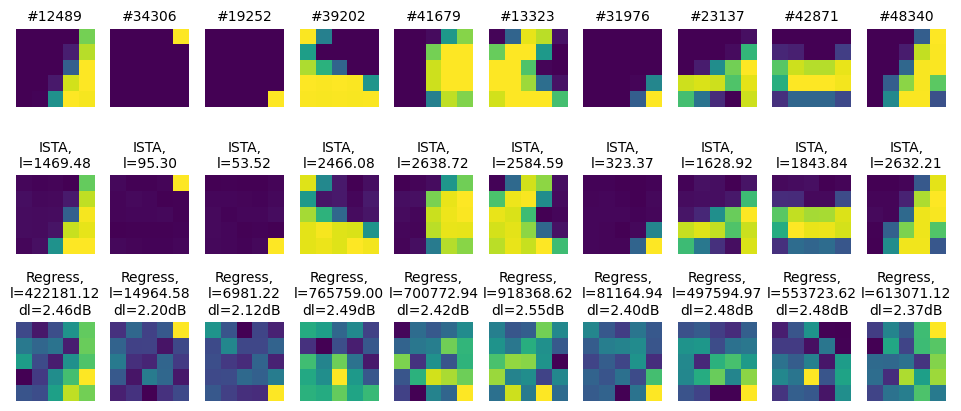

In [146]:
# @launchit.disable
example_inds = RNG.choice(len(PATCHES), 10, replace=False)
fig, axes = plt.subplots(3, len(example_inds))
fig.set_figwidth(12)
fig.set_figheight(len(axes) * 1.8)
for ax in axes.ravel(): ax.set_axis_off()
W = main_model.W.weight.detach()
max_index = W.shape[1] - 1
L = scipy.linalg.eigvalsh((W.t() @ W).to('cpu'), subset_by_index=(max_index, max_index)).item()

for example_ind, (ax0, ax1, ax2) in zip(example_inds, axes.T):
    patch = PATCHES[example_ind]
    ax0.set_title(f'#{example_ind}', fontdict=dict(fontsize=10))
    ax0.imshow(ArrayUtils.v2sm(patch))
    
    ista_z = ista(patch, W, rho=HP.basis_pursuit_rho, L=L, iters_count=HP.basis_pursuit_iters_count)
    ista_patch = W @ ista_z
    ista_l = ((patch - ista_patch) ** 2).sum()
    ax1.set_title(f'{HP.basis_pursuit_solver},\nl={ista_l:.2f}', fontdict=dict(fontsize=10))
    ax1.imshow(ArrayUtils.v2sm(ista_patch))
    
    regress_z = main_model.regress(einops.rearrange(patch, 'v -> 1 v')).squeeze(0).detach()
    regress_patch = W @ regress_z
    regress_l = ((patch - regress_patch) ** 2).sum()
    #dl = (regress_l - ista_l) / ista_l
    dl = np.log10((regress_l / ista_l).item())
    ax2.set_title(f'Regress,\nl={regress_l:.2f}\ndl={dl:.2f}dB', fontdict=dict(fontsize=10))
    ax2.imshow(ArrayUtils.v2sm(regress_patch))

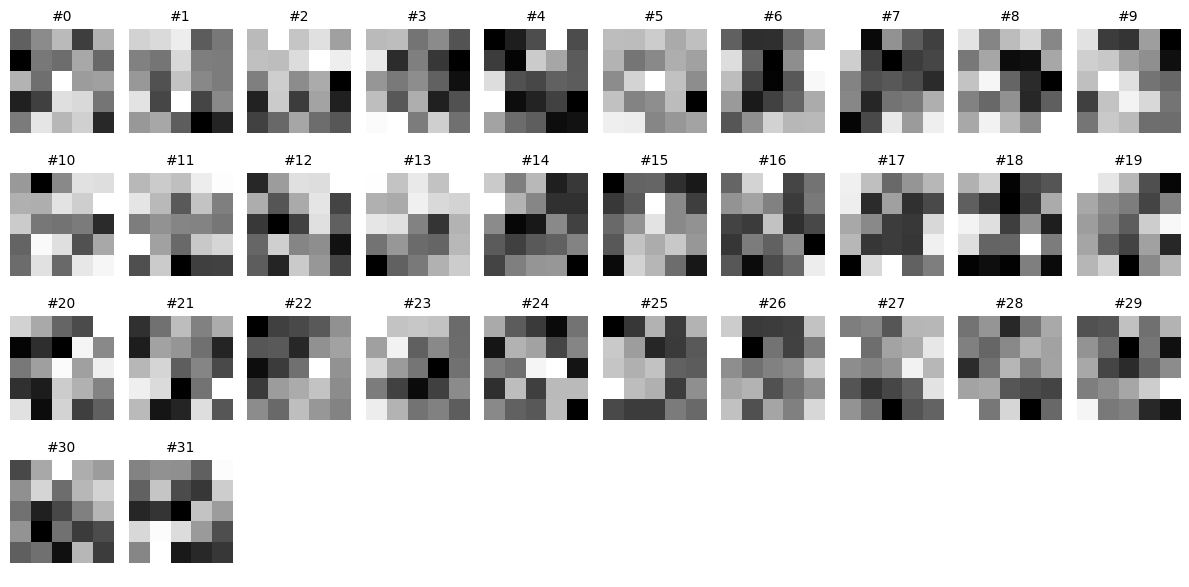

In [101]:
# @launchit.disable
kernes_in_row = 10
max_kernels_to_show = 100
kernels = main_model.K.weight.to(device='cpu').detach()
rows_count = int(np.ceil(min(max_kernels_to_show, len(kernels)) / kernes_in_row))
fig, axes = plt.subplots(rows_count, kernes_in_row, subplot_kw={'yticks': [], 'xticks': []})
for ax in axes.ravel(): ax.set_axis_off()
fig.set_figwidth(12)
fig.set_figheight(rows_count * 1.5)

if main_model.K.bias is not None:
    biases = main_model.K.bias.to(device='cpu').detach()
    kernels = einops.rearrange(kernels, 'k hw -> hw k')
    kernels = kernels + biases
    kernels = einops.rearrange(kernels, 'hw k -> k hw')

for i, (k, ax) in enumerate(zip(kernels, axes.ravel())):
    k = k.squeeze() 
    ax.set_title(f'#{i}', fontdict=dict(fontsize=10))
    ax.imshow(ArrayUtils.v2sm(k), cmap='gray')

plt.tight_layout()

## Save

In [151]:
model_registry = new_model_registry()

with io.BytesIO() as b:
    torch.save({
        'model_state_dict': main_model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'hypers': HP._asdict(),
    }, b)
    model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='pt', asset_classifier='main', replace=True)

with io.BytesIO() as b:
    np.save(b, main_model.K.weight.detach().to('cpu').numpy())
    model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='npy', asset_classifier='kernels', replace=True)

with io.BytesIO() as b:
    np.save(b, main_model.K.bias.detach().to('cpu').numpy())
    model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='npy', asset_classifier='biases', replace=True)

# with io.BytesIO() as b:
#     np.save(b, main_model.gain.detach().to('cpu').numpy())
#     model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='npy', asset_classifier='gains', replace=True)

with io.StringIO() as b:
    json.dump(METRICS_SUITE, b)
    model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='json', asset_classifier='metrics', replace=True)

# Save Optuna trial result

In [121]:
# # @launchit.disable
# optuna_trial = optuna_multiprocessing.get_trial()

# if optuna_trial is not None:
#     if 'IS_PRUNED' in optuna_trial.user_attrs:
#         raise optuna.exceptions.TrialPruned()

#     if not METRICS_SUITE:
#         LOG(f'Empty metrics suite. Cancelling model')
#         optuna_multiprocessing.save_trial_result(0)
#     else:
#         match LAUNCH_GOAL.goal:
#             case LaunchGoal.TRAIN_COMPLETE_MODEL_CV:
#                 last_std_val_accuracy = METRICS_SUITE['std_val_accuracy'][-1]
#                 last_mean_val_accuracy = METRICS_SUITE['mean_val_accuracy'][-1]
                    
#                 if last_std_val_accuracy > 0.05:
#                     LOG(f'Unstable condition encountered: {last_mean_val_accuracy=}, {last_std_val_accuracy=}. Cancelling model')
#                     optuna_multiprocessing.save_trial_result(0)
#                 else:
#                     optuna_multiprocessing.save_trial_result(last_mean_val_accuracy)
#                     LOG(f'Train objective result={last_mean_val_accuracy}')
#             case _:
#                 assert False, f'Unsupported {LAUNCH_GOAL.goal=}'

# Launch creation

## PRETRAIN_KERNELS

In [15]:
# @launchit.disable
launchit_t0 = time.time()

In [17]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    model_version = int(Autoincrement.get(f'{LAUNCH_GOAL.model_group_uri}.{LAUNCH_GOAL.model_name}'))
    assert model_version > 0, model_version
    model_registry_obj = new_model_registry(is_real=True)
    model_registry_obj.register_model(LAUNCH_GOAL.model_name, model_version)
    LOG(f'Model instance registered, version={model_version}')
    
    expandvars = dict(
        PROJECT_ROOT_PATH=CONFIG.project_root_path,
        MODEL_GROUP_URI=LAUNCH_GOAL.model_group_uri,
        MODEL_NAME=LAUNCH_GOAL.model_name,
        MODEL_VERSION=model_version,
        LAUNCH_GOAL=LaunchGoal.PRETRAIN_KERNELS.value,
    )
    launch_notebook_fname = launchit.launchit(CONFIG.self_fname, launch_serial=model_version, expandvars=expandvars)
    LOG(f'Created launch notebook "{launch_notebook_fname}"')
else:
    LOG('Skip launchit due to mass "Run Cells"')

Model instance registered, version=2
Creating /home/misha/dev/mine/neurovision/11_cnn/s4_cnn_01-launch2.ipynb
Created launch notebook "/home/misha/dev/mine/neurovision/11_cnn/s4_cnn_01-launch2.ipynb"


## Optuna (model selection)

### Template "PRETRAIN_LOSS"

In [ ]:
# @launchit.disable
optuna_trial = optuna_multiprocessing.get_trial()

if optuna_trial is not None:
    HP.random_seed = optuna_trial.suggest_categorical('random_seed', [3, 7, 42, 82, 100, 1945])
    
    HP.images.preprocessing = 'UNINORM'
    
    HP.pretrain_model.daes_count = 3
    HP.pretrain_model.filters_count = 1000
    HP.pretrain_model.is_tied_weights = True
    HP.pretrain_model.is_bias = True
    HP.pretrain_model.nonlinearity = {'encoder': 'sigmoid', 'decoder': 'sigmoid'}
    HP.pretrain_model.inp_dropout = 0.5 # analog to 'Masking_0.5', but much faster
    HP.pretrain_model.hid_dropout = 0.5 # analog to 'Masking_0.5', but much faster
    
    HP.pretraining.batch_size = 1000
    HP.pretraining.epochs_count = 300
    HP.pretraining.noise = 'None'
    HP.pretraining.optimizer = 'Adam'
    HP.pretraining.learn_rate = optuna_trial.suggest_float('pretraining.learn_rate', 0.004, 0.006)
    HP.pretraining.loss = 'BCE'
    HP.pretraining.regularization = None
    
    HP.training.batch_size = 500
    HP.training.epochs_count = 0
    HP.training.optimizer = 'Adam'
    HP.training.learn_rate = 1
    HP.training.cv_folds_count = 5

### Unleash

In [ ]:
# @launchit.disable
def get_optimize_directions(LAUNCH_GOAL):
    match LAUNCH_GOAL:
        case LaunchGoal.PRETRAIN_LOSS:
            return ['minimize'] * 3
        case LaunchGoal.E2E:
            return ['maximize']
        case _:
            assert False, f'Unsupported {LAUNCH_GOAL=}'

LAUNCH_GOAL = LaunchGoal.PRETRAIN_LOSS
expandvars = dict(
    PROJECT_ROOT_PATH=CONFIG.project_root_path,
    MODEL_GROUP_URI=LAUNCH_GOAL.model_group_uri,
    MODEL_NAME=LAUNCH_GOAL.model_name,
    LAUNCH_GOAL=LAUNCH_GOAL.value,
)
# study_name = f'{CONFIG.self_name}_{expandvars['LAUNCH_GOAL']}'
study_name = f'{CONFIG.self_name}_{expandvars['LAUNCH_GOAL']}_v3'
# study_name = CONFIG.self_name + '_e2e_2'
# study_name = CONFIG.self_name + '_supervised_over_71'
# study_name = CONFIG.self_name + '_pretraining2'
rop_task = optuna_multiprocessing.RunOptimizationTask(
    app_name=CONFIG.self_name,
    is_stdout_enabled=False,
    notebook_fname=CONFIG.self_fname,
    notebook_name=CONFIG.self_name,
    model_group_uri=LAUNCH_GOAL.model_group_uri,
    model_name=LAUNCH_GOAL.model_name,
    expandvars=expandvars,
    collect_inds=[2],
    disable_inds=[2],
    run_path=CONFIG.run_path,
    study_name=study_name,
    study_fname=os.path.join(CONFIG.run_path, study_name + '.log'),
    optimize_directions=get_optimize_directions(LAUNCH_GOAL),
)
rop_tasks = [rop_task] * 40
mp_ctx = mp.get_context('spawn') # Req-d for CUDA, fork doesn't work within PyTorch

with mp_ctx.Pool(processes=4, maxtasksperchild=1) as pool:  # maxtasksperchild=1 forces fresh process for each trial to spare resources and avoid possible side effects of processe resue
    pool.map(optuna_multiprocessing.run_optimization, rop_tasks)

In [9]:
# @launchit.disable
study = optuna.create_study(
    study_name=rop_task.study_name,
    storage=JournalStorage(JournalFileBackend(file_path=rop_task.study_fname)),
    load_if_exists=True, 
)

pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

LOG('Study statistics: ')
LOG(f'\tNumber of finished trials: {len(study.trials)}')
LOG(f'\tNumber of pruned trials: {len(pruned_trials)}')
LOG(f'\tNumber of complete trials: {len(complete_trials)}')

if len(study.directions) == 1:
    LOG('Best trial:')
    trial = study.best_trial
    
    LOG(f'\tValue: {trial.value}')
    LOG(f'\tModel version: {trial.user_attrs['MODEL_VERSION']}')
    
    LOG('  Params: ')
    for key, value in trial.params.items():
        LOG(f'\t\t{key}: {value}')
else:
    print(f"Number of trials on the Pareto front: {len(study.best_trials)}")

    for i in range(3):
        print(f"Trial with lowest loss_{i}:")
        trial = min(study.best_trials, key=lambda t: t.values[i])
        print(f"\tnumber: {trial.number}")
        print(f"\tmver: {trial.user_attrs['MODEL_VERSION']}")
        print(f"\tparams: {trial.params}")
        print(f"\tvalues: {trial.values}")

[I 2026-02-01 22:55:59,249] Using an existing study with name 's3_stacked_dae_09_pretrain_loss_v3' instead of creating a new one.


Study statistics: 
	Number of finished trials: 40
	Number of pruned trials: 0
	Number of complete trials: 40
Number of trials on the Pareto front: 6
Trial with lowest loss_0:
	number: 26
	mver: 387
	params: {'random_seed': 42, 'pretraining.learn_rate': 0.005492061413625679}
	values: [0.08833594769239425, 0.11375552080571652, 0.056806695212920505]
Trial with lowest loss_1:
	number: 5
	mver: 366
	params: {'random_seed': 7, 'pretraining.learn_rate': 0.005999620308115563}
	values: [0.08838711865246296, 0.1107913492868344, 0.0565817362939318]
Trial with lowest loss_2:
	number: 33
	mver: 394
	params: {'random_seed': 42, 'pretraining.learn_rate': 0.005927765975396279}
	values: [0.08837893058856329, 0.11239499002695083, 0.054594331855575245]


In [31]:
# @launchit.disable
train_images, _ = get_mnist_images('TRAIN')
model_registry = new_model_registry(is_real=True)
meta = json.load(io.BytesIO(model_registry.get_asset_content(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, asset_ext='json', asset_classifier='meta')))
old_hp = Hyperparameters.from_dict(meta['hypers'])
LOG(pprint.pformat(old_hp._asdict(), sort_dicts=False))

pretrain_model = StackedDAE(train_images.shape[1], old_hp.pretrain_model)
pretrain_model = pretrain_model.to(device=CONFIG.cuda_device)
pt_data = model_registry.get_asset_content(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, asset_ext='pt', pretrain_stacked_dae_asset_classifier)
pt_data = io.BytesIO(initial_bytes=pt_data)
checkpoint = torch.load(pt_data, map_location=torch.device(CONFIG.cuda_device))

if pretrain_stacked_dae_asset == 'pretrain_pt':
    pretrain_model.load_state_dict(checkpoint['model_state_dict'])
elif pretrain_stacked_dae_asset == 'train_pt':
    fined_tuned_model = DeepLinearRegression(pretrain_model, 10)
    fined_tuned_model.load_state_dict(checkpoint['model_state_dict']) # implicit load of pretrain model
else:
    assert False, pretrain_stacked_dae_asset
    
pretrain_model.eval()

{'images': {'preprocessing': 'UNINORM'},
 'override_pretrain_model_version': None,
 'pretrain_model': {'daes_count': 3,
                    'filters_count': 1000,
                    'is_bias': True,
                    'is_tied_weights': True,
                    'nonlinearity': {'decoder': 'sigmoid',
                                     'encoder': 'sigmoid'}},
 'pretraining': {'batch_size': 1000,
                 'epochs_count': 300,
                 'learn_rate': 0.01,
                 'loss': 'BCE',
                 'noise': 'Masking_0.4',
                 'optimizer': 'Adam',
                 'regularization': None},
 'random_seed': None,
 'training': {'batch_size': 1000,
              'epochs_count': 500,
              'learn_rate': 0.001,
              'optimizer': 'Adam'}}


StackedDAE(
  (daes): ModuleList(
    (0): DenoiseAutoencoder(
      (encoder): Linear(in_features=784, out_features=1000, bias=True)
    )
    (1-2): 2 x DenoiseAutoencoder(
      (encoder): Linear(in_features=1000, out_features=1000, bias=True)
    )
  )
)